In [2]:
import numpy as np
import matplotlib.pyplot as plt
from parametrizations import Parameter
from geometry_class import Geometry

In [60]:
geom = Geometry()
domain = geom.make_domain()
p = Parameter(domain)
minhw = p.min_hw.value
hws = np.linspace(-1, 0, 100)
def Se(hw):
    S = np.ones_like(hw)
    hw_safe = np.clip(hw, minhw, -1e-8)
    a = p.alpha.value
    n = p.N.value
    S[hw < -1e-8] = (1 + (-a*hw_safe[hw < -1e-8])**n) ** ((1-n)/n)
    return S

S_e = Se(hws)
def theta(S):
    return p.theta_r.value + S*(0.9*0.468 - p.theta_r.value)
t = theta(S_e)

In [61]:
def krel(Se):
    N = p.N.value
    m = 1 - 1/N
    krel = np.sqrt(Se) * (1 - (1-Se**(1/m))**m)**2
    return krel
kr = krel(S_e)

Text(0, 0.5, 'h_w [m]')

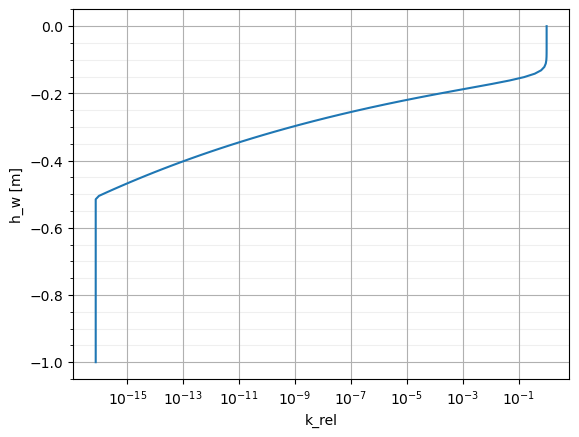

In [64]:
plt.semilogx(kr, hws)
plt.grid(True, which="major")
plt.grid(True, which="minor", alpha=0.2)
plt.minorticks_on()
plt.xlabel("k_rel")
plt.ylabel("h_w [m]")